# Day 4 - Fund Performance Analytics

This notebook computes return, risk and benchmark metrics for the Bluestock mutual fund dataset. I kept the calculations in separate blocks so that it is easier to review and explain during evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress

DATA = Path('../data/raw')
OUT = Path('../data/processed')
CHARTS = Path('../reports/charts')
OUT.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

fund_master = pd.read_csv(DATA / '01_fund_master.csv')
nav = pd.read_csv(DATA / '02_nav_history.csv')
bench = pd.read_csv(DATA / '10_benchmark_indices.csv')

fund_master['amfi_code'] = fund_master['amfi_code'].astype(str)
nav['amfi_code'] = nav['amfi_code'].astype(str)
nav['date'] = pd.to_datetime(nav['date'])
bench['date'] = pd.to_datetime(bench['date'])

nav = nav.drop_duplicates(['amfi_code', 'date']).sort_values(['amfi_code', 'date'])
nav = nav[nav['nav'] > 0].copy()
nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


## 1. Daily returns

Daily return is calculated scheme-wise using NAV percentage change. The first row for every scheme is expected to be blank because there is no previous NAV value for comparison.

In [2]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
print(nav['daily_return'].describe())

nav.to_csv(OUT / 'returns_computed.csv', index=False)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


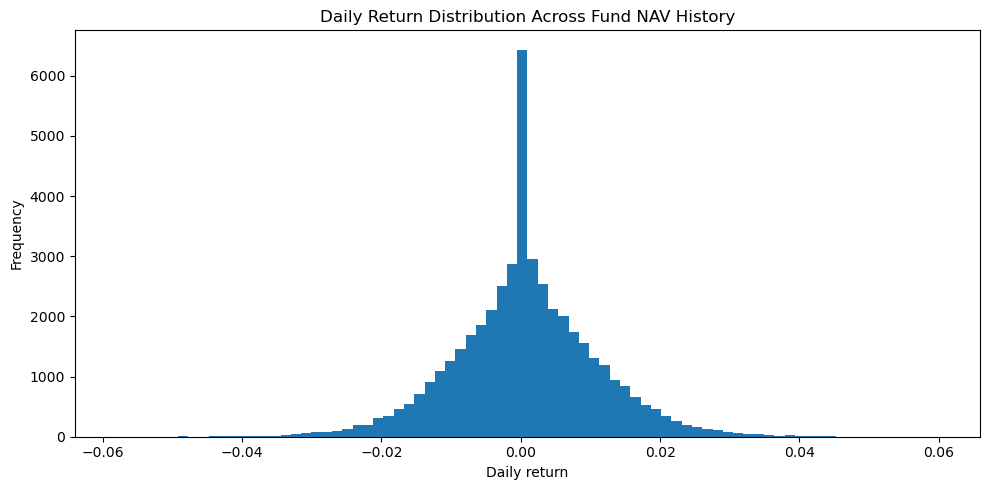

In [3]:
plt.figure(figsize=(10,5))
plt.hist(nav['daily_return'].dropna().clip(-0.06, 0.06), bins=80)
plt.title('Daily Return Distribution Across Fund NAV History')
plt.xlabel('Daily return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(CHARTS / 'daily_return_distribution.png', dpi=150)
plt.show()

The return distribution is mostly centred around zero, which is expected for daily NAV returns. A few larger positive and negative days are present, but they are not dominating the overall distribution.

In [4]:
bench = bench.sort_values(['index_name', 'date'])
bench['benchmark_return'] = bench.groupby('index_name')['close_value'].pct_change()
nifty100 = bench[bench['index_name'] == 'NIFTY100'][['date', 'benchmark_return']].dropna()
nifty100 = nifty100.rename(columns={'benchmark_return': 'nifty100_return'})

## 2. CAGR, Sharpe, Sortino, Alpha, Beta and Drawdown

Risk-free rate is taken as 6.5% annually. Alpha and beta are calculated using daily fund returns against NIFTY 100 daily returns.

In [5]:
def cagr_for_group(g, years):
    end_date = g['date'].max()
    start_cut = end_date - pd.DateOffset(years=years)
    hist = g[g['date'] >= start_cut].sort_values('date')
    if len(hist) < 2:
        return np.nan
    start_nav = hist.iloc[0]['nav']
    end_nav = hist.iloc[-1]['nav']
    actual_years = (hist.iloc[-1]['date'] - hist.iloc[0]['date']).days / 365.25
    if actual_years <= 0 or start_nav <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / actual_years) - 1

def max_dd_info(g):
    g = g.sort_values('date').copy()
    running_max = g['nav'].cummax()
    drawdown = g['nav'] / running_max - 1
    trough_idx = drawdown.idxmin()
    peak_nav = running_max.loc[trough_idx]
    peak_rows = g.loc[:trough_idx][g.loc[:trough_idx, 'nav'] == peak_nav]
    peak_date = peak_rows.iloc[-1]['date'] if len(peak_rows) else pd.NaT
    trough_date = g.loc[trough_idx, 'date']
    return drawdown.min(), peak_date, trough_date

In [6]:
rf = 0.065
records = []

for code, g in nav.groupby('amfi_code'):
    g = g.sort_values('date')
    r = g['daily_return'].dropna()
    ann_return = (1 + r.mean()) ** 252 - 1
    ann_std = r.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_std if ann_std > 0 else np.nan
    downside = r[r < 0]
    downside_std = downside.std() * np.sqrt(252)
    sortino = (ann_return - rf) / downside_std if downside_std > 0 else np.nan

    max_dd, peak_date, trough_date = max_dd_info(g)

    merged = g[['date', 'daily_return']].dropna().merge(nifty100, on='date', how='inner')
    if len(merged) > 20:
        lr = linregress(merged['nifty100_return'], merged['daily_return'])
        alpha = lr.intercept * 252
        beta = lr.slope
        r_squared = lr.rvalue ** 2
    else:
        alpha, beta, r_squared = np.nan, np.nan, np.nan

    records.append({
        'amfi_code': code,
        'return_1yr_pct': cagr_for_group(g, 1) * 100,
        'return_3yr_pct': cagr_for_group(g, 3) * 100,
        'return_5yr_pct': cagr_for_group(g, 5) * 100,
        'annualised_return_pct': ann_return * 100,
        'annualised_volatility_pct': ann_std * 100,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_squared,
        'max_drawdown_pct': max_dd * 100,
        'drawdown_start': peak_date,
        'drawdown_end': trough_date
    })

metrics = pd.DataFrame(records)
metrics = metrics.merge(
    fund_master[['amfi_code','scheme_name','fund_house','category','sub_category','expense_ratio_pct','benchmark','risk_category']],
    on='amfi_code', how='left'
)
metrics.head()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,annualised_return_pct,annualised_volatility_pct,sharpe_ratio,sortino_ratio,alpha,beta,...,max_drawdown_pct,drawdown_start,drawdown_end,scheme_name,fund_house,category,sub_category,expense_ratio_pct,benchmark,risk_category
0,100016,-2.225777,1.292353,2.637074,3.632469,14.548135,-0.197106,-0.343364,0.037476,-0.058268,...,-24.734441,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,NIFTY 100 TRI,Moderate
1,100025,3.707553,3.915479,4.458210,4.378122,3.905246,-0.543340,-0.902370,0.042818,0.001158,...,-4.308264,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Short Duration,0.56,CRISIL Short Term Bond Index,Low
2,100033,53.277195,32.433971,30.123153,31.253944,18.936711,1.307193,2.186189,0.271954,0.005104,...,-16.217209,2022-03-11,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,1.38,NIFTY Midcap 150 TRI,High
3,101206,47.963794,28.960211,23.538361,23.931060,14.568213,1.196513,2.096157,0.213998,0.021086,...,-11.291596,2023-04-24,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.60,NIFTY 100 TRI,Moderate
4,101207,-24.000309,-4.151454,7.938765,11.286684,25.797322,0.185550,0.315572,0.108971,-0.065289,...,-35.446916,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,1.53,BSE 250 SmallCap TRI,Very High


In [7]:
metrics.sort_values('sharpe_ratio', ascending=False).head(10)[
    ['scheme_name','fund_house','return_3yr_pct','sharpe_ratio','sortino_ratio','alpha','beta','max_drawdown_pct']
]

,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,33.991970,1.729753,2.849273,0.269838,0.023684,-11.265729
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.575111,1.562186,2.826496,0.273305,-0.022830,-12.973968
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,29.171358,1.483768,2.579516,0.282704,0.018134,-16.396743
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.769243,1.424242,2.449188,0.292636,0.000549,-18.188514
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.448613,1.417375,2.510672,0.232010,-0.031751,-15.012385
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,26.863104,1.349207,2.234652,0.265986,-0.002523,-17.248106
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.433971,1.307193,2.186189,0.271954,0.005104,-16.217209
9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,22.646647,1.261743,2.158158,0.218294,-0.008354,-17.414075
3,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.960211,1.196513,2.096157,0.213998,0.021086,-11.291596
24,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.478927,1.194607,2.100892,0.211948,0.016232,-12.588276


In [8]:
metrics.to_csv(OUT / 'performance_metrics.csv', index=False)
metrics[['amfi_code','scheme_name','fund_house','alpha','beta','r_squared','benchmark']].sort_values('alpha', ascending=False).to_csv(OUT / 'alpha_beta.csv', index=False)
metrics[['amfi_code','scheme_name','return_1yr_pct','return_3yr_pct','return_5yr_pct']].sort_values('return_3yr_pct', ascending=False).to_csv(OUT / 'cagr_report.csv', index=False)

## 3. Fund scorecard

The composite score gives higher weight to three-year return and Sharpe ratio, while still considering alpha, expense ratio and drawdown control.

In [9]:
def pct_rank(s, ascending=True):
    return s.rank(pct=True, ascending=ascending) * 100

score = metrics.copy()
score['score_3yr_return'] = pct_rank(score['return_3yr_pct'], ascending=True)
score['score_sharpe'] = pct_rank(score['sharpe_ratio'], ascending=True)
score['score_alpha'] = pct_rank(score['alpha'], ascending=True)
score['score_expense'] = pct_rank(score['expense_ratio_pct'], ascending=False)
score['score_drawdown'] = pct_rank(score['max_drawdown_pct'], ascending=True)

score['fund_score'] = (
    0.30 * score['score_3yr_return'] +
    0.25 * score['score_sharpe'] +
    0.20 * score['score_alpha'] +
    0.15 * score['score_expense'] +
    0.10 * score['score_drawdown']
).round(2)

fund_scorecard = score[[
    'amfi_code','scheme_name','fund_house','category','sub_category','return_3yr_pct',
    'sharpe_ratio','alpha','expense_ratio_pct','max_drawdown_pct','fund_score'
]].sort_values('fund_score', ascending=False)

fund_scorecard.to_csv(OUT / 'fund_scorecard.csv', index=False)
fund_scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,sub_category,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,fund_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Large Cap,33.991970,1.729753,0.269838,1.46,-11.265729,86.25
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,31.769243,1.424242,0.292636,1.36,-18.188514,82.88
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Flexi Cap,29.575111,1.562186,0.273305,1.45,-12.973968,82.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,32.433971,1.307193,0.271954,1.38,-16.217209,80.75
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Large Cap,32.478927,1.194607,0.211948,0.80,-12.588276,80.00
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Mid Cap,35.102528,1.185696,0.260767,1.38,-20.960884,77.00
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,30.448613,1.417375,0.232010,1.54,-15.012385,74.19
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,ELSS,29.171358,1.483768,0.282704,1.60,-16.396743,73.69
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,28.960211,1.196513,0.213998,1.60,-11.291596,68.19
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,26.663091,1.146366,0.303370,1.43,-28.706006,68.00


## 4. Benchmark comparison and tracking error

For the chart, the top five scorecard funds are indexed to 100 and compared with NIFTY 50 and NIFTY 100 over the latest three-year period.

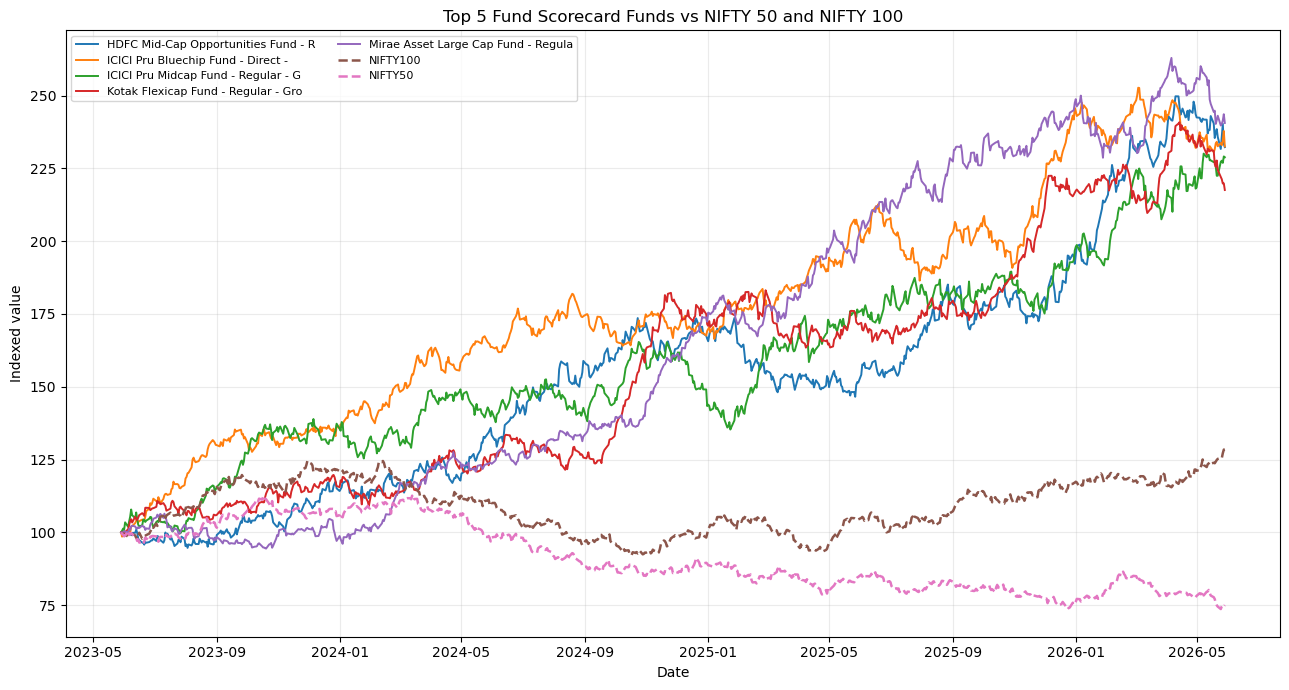

In [10]:
end = nav['date'].max()
start = end - pd.DateOffset(years=3)
top5_codes = fund_scorecard.head(5)['amfi_code'].tolist()
plot_nav = nav[(nav['amfi_code'].isin(top5_codes)) & (nav['date'] >= start)]
plot_nav = plot_nav.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')
bench_subset = bench[(bench['index_name'].isin(['NIFTY50','NIFTY100'])) & (bench['date'] >= start)]

plt.figure(figsize=(13,7))
for code, g in plot_nav.groupby('amfi_code'):
    g = g.sort_values('date')
    indexed = g['nav'] / g['nav'].iloc[0] * 100
    plt.plot(g['date'], indexed, linewidth=1.4, label=g['scheme_name'].iloc[0][:35])

for idx_name, g in bench_subset.groupby('index_name'):
    g = g.sort_values('date')
    indexed = g['close_value'] / g['close_value'].iloc[0] * 100
    plt.plot(g['date'], indexed, linestyle='--', linewidth=1.8, label=idx_name)

plt.title('Top 5 Fund Scorecard Funds vs NIFTY 50 and NIFTY 100')
plt.xlabel('Date')
plt.ylabel('Indexed value')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(CHARTS / 'benchmark_comparison_top5.png', dpi=160)
plt.show()

In [11]:
tracking_rows = []
bench_returns = bench[bench['index_name'].isin(['NIFTY50','NIFTY100'])][['date','index_name','benchmark_return']].dropna()

for code in top5_codes:
    fund_returns = nav[nav['amfi_code'] == code][['date','daily_return']].dropna()
    fund_name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].iloc[0]
    for idx_name in ['NIFTY50','NIFTY100']:
        br = bench_returns[bench_returns['index_name'] == idx_name][['date','benchmark_return']]
        merged = fund_returns.merge(br, on='date', how='inner')
        merged = merged[merged['date'] >= start]
        tracking_error = (merged['daily_return'] - merged['benchmark_return']).std() * np.sqrt(252) * 100
        tracking_rows.append({
            'amfi_code': code,
            'scheme_name': fund_name,
            'benchmark': idx_name,
            'tracking_error_pct': tracking_error,
            'observations': len(merged)
        })

tracking_error = pd.DataFrame(tracking_rows)
tracking_error.to_csv(OUT / 'tracking_error.csv', index=False)
tracking_error

,amfi_code,scheme_name,benchmark,tracking_error_pct,observations
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.181717,785
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.786717,785
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.831056,785
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.251471,785
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.494647,785
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.641015,785
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.808081,785
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.483819,785
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,18.835968,785
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,18.731172,785


## Notes / Findings

1. Daily returns are centred close to zero, which is reasonable for daily NAV movement.
2. The scorecard is more balanced than ranking only by returns because it includes risk, alpha, expense ratio and drawdown.
3. Sharpe ratio helps identify funds where the return is better adjusted for volatility.
4. Sortino ratio is useful here because it focuses only on negative-return days.
5. Beta values close to 1 suggest funds moving broadly in line with NIFTY 100.
6. Positive alpha suggests outperformance after accounting for market movement.
7. Maximum drawdown highlights the worst peak-to-trough fall and is important for risk discussion.
8. The benchmark comparison chart uses indexed values, so the chart focuses on relative growth instead of absolute NAV levels.
9. Tracking error shows how closely or loosely the top scorecard funds moved versus NIFTY 50 and NIFTY 100.
10. The final scorecard should not be read as investment advice; it is a project ranking model based on selected metrics.